<a href="https://colab.research.google.com/github/manojmulammagari/Car-Price-Prediction/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

In [66]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Install with: pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not installed. Install with: pip install lightgbm")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,mean_absolute_percentage_error, explained_variance_score
import joblib
import json
from datetime import datetime
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [23]:
df = pd.read_csv('cardekho_dataset.csv')
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")


Shape: 15411 rows x 14 columns


In [24]:
print("\n--- First 5 Rows ---")
df.head()


--- First 5 Rows ---


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15244 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15244 non-null  object 
 1   brand              15244 non-null  object 
 2   model              15244 non-null  object 
 3   vehicle_age        15244 non-null  int64  
 4   km_driven          15244 non-null  int64  
 5   seller_type        15244 non-null  object 
 6   fuel_type          15244 non-null  object 
 7   transmission_type  15244 non-null  object 
 8   mileage            15244 non-null  float64
 9   engine             15244 non-null  int64  
 10  max_power          15244 non-null  float64
 11  seats              15244 non-null  int64  
 12  selling_price      15244 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


In [44]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.000000,1.524400e+04,15244.000000,15244.000000,15244.000000,15244.000000,1.524400e+04
mean,6.041131,5.563958e+04,19.697333,1486.171543,100.607652,5.326161,7.747014e+05
std,3.016228,5.176630e+04,4.169307,520.419390,42.915687,0.808760,8.946761e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.590000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [25]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

In [29]:
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0
engine,0


In [30]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()


Duplicate rows: 167


In [26]:
print("\n--- Categorical Summary ---")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))


--- Categorical Summary ---

car_name: 121 unique values
car_name
Hyundai i20           906
Maruti Swift Dzire    890
Maruti Swift          781
Maruti Alto           778
Honda City            757
Maruti Wagon R        717
Hyundai Grand         580
Toyota Innova         545
Hyundai Verna         492
Hyundai i10           410
Name: count, dtype: int64

brand: 32 unique values
brand
Maruti        4992
Hyundai       2982
Honda         1485
Mahindra      1011
Toyota         793
Ford           790
Volkswagen     620
Renault        536
BMW            439
Tata           430
Name: count, dtype: int64

model: 120 unique values
model
i20            906
Swift Dzire    890
Swift          781
Alto           778
City           757
Wagon R        717
Grand          580
Innova         545
Verna          492
i10            410
Name: count, dtype: int64

seller_type: 3 unique values
seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64

fuel_typ

#EDA


STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

--- Target Variable: Selling Price ---
count    1.524400e+04
mean     7.747014e+05
std      8.946761e+05
min      4.000000e+04
25%      3.850000e+05
50%      5.590000e+05
75%      8.250000e+05
max      3.950000e+07
Name: selling_price, dtype: float64


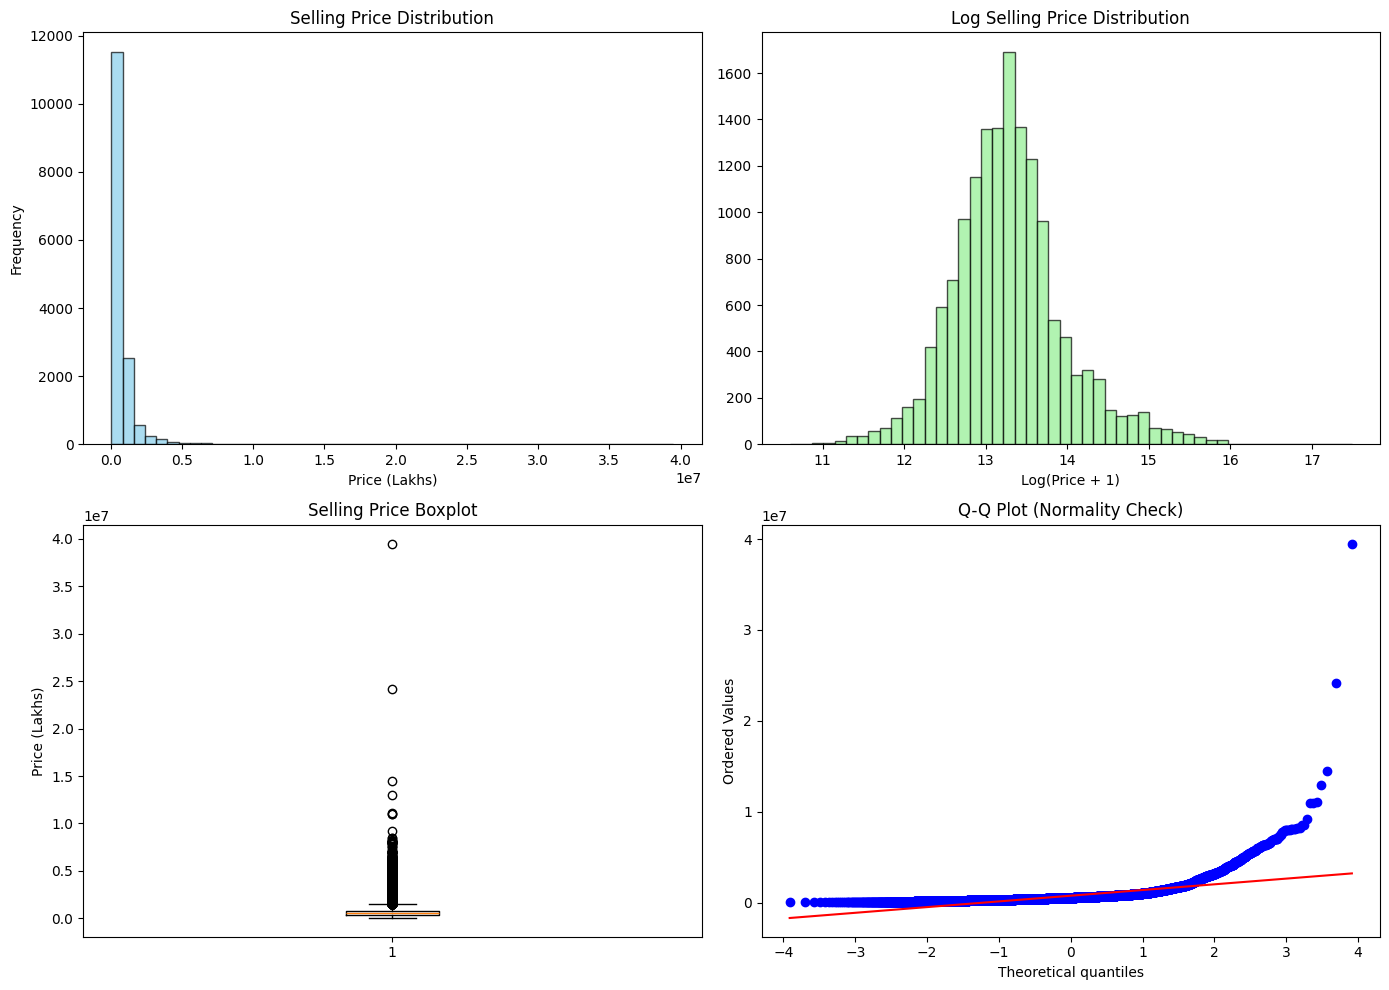


Skewness: 10.108
Kurtosis: 284.189


In [48]:
print("\n" + "=" * 80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

# Target Variable Analysis
print("\n--- Target Variable: Selling Price ---")
print(df['selling_price'].describe())

# THIS IS WHAT WAS MISSING: Building the 2x2 grid canvas before plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution
axes[0, 0].hist(df['selling_price'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Selling Price Distribution')
axes[0, 0].set_xlabel('Price (Lakhs)')
axes[0, 0].set_ylabel('Frequency')

# Log-transformed distribution
axes[0, 1].hist(np.log1p(df['selling_price']), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Log Selling Price Distribution')
axes[0, 1].set_xlabel('Log(Price + 1)')

# Boxplot
axes[1, 0].boxplot(df['selling_price'])
axes[1, 0].set_title('Selling Price Boxplot')
axes[1, 0].set_ylabel('Price (Lakhs)')

# Q-Q plot
stats.probplot(df['selling_price'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()

print(f"\nSkewness: {skew(df['selling_price']):.3f}")
print(f"Kurtosis: {kurtosis(df['selling_price']):.3f}")

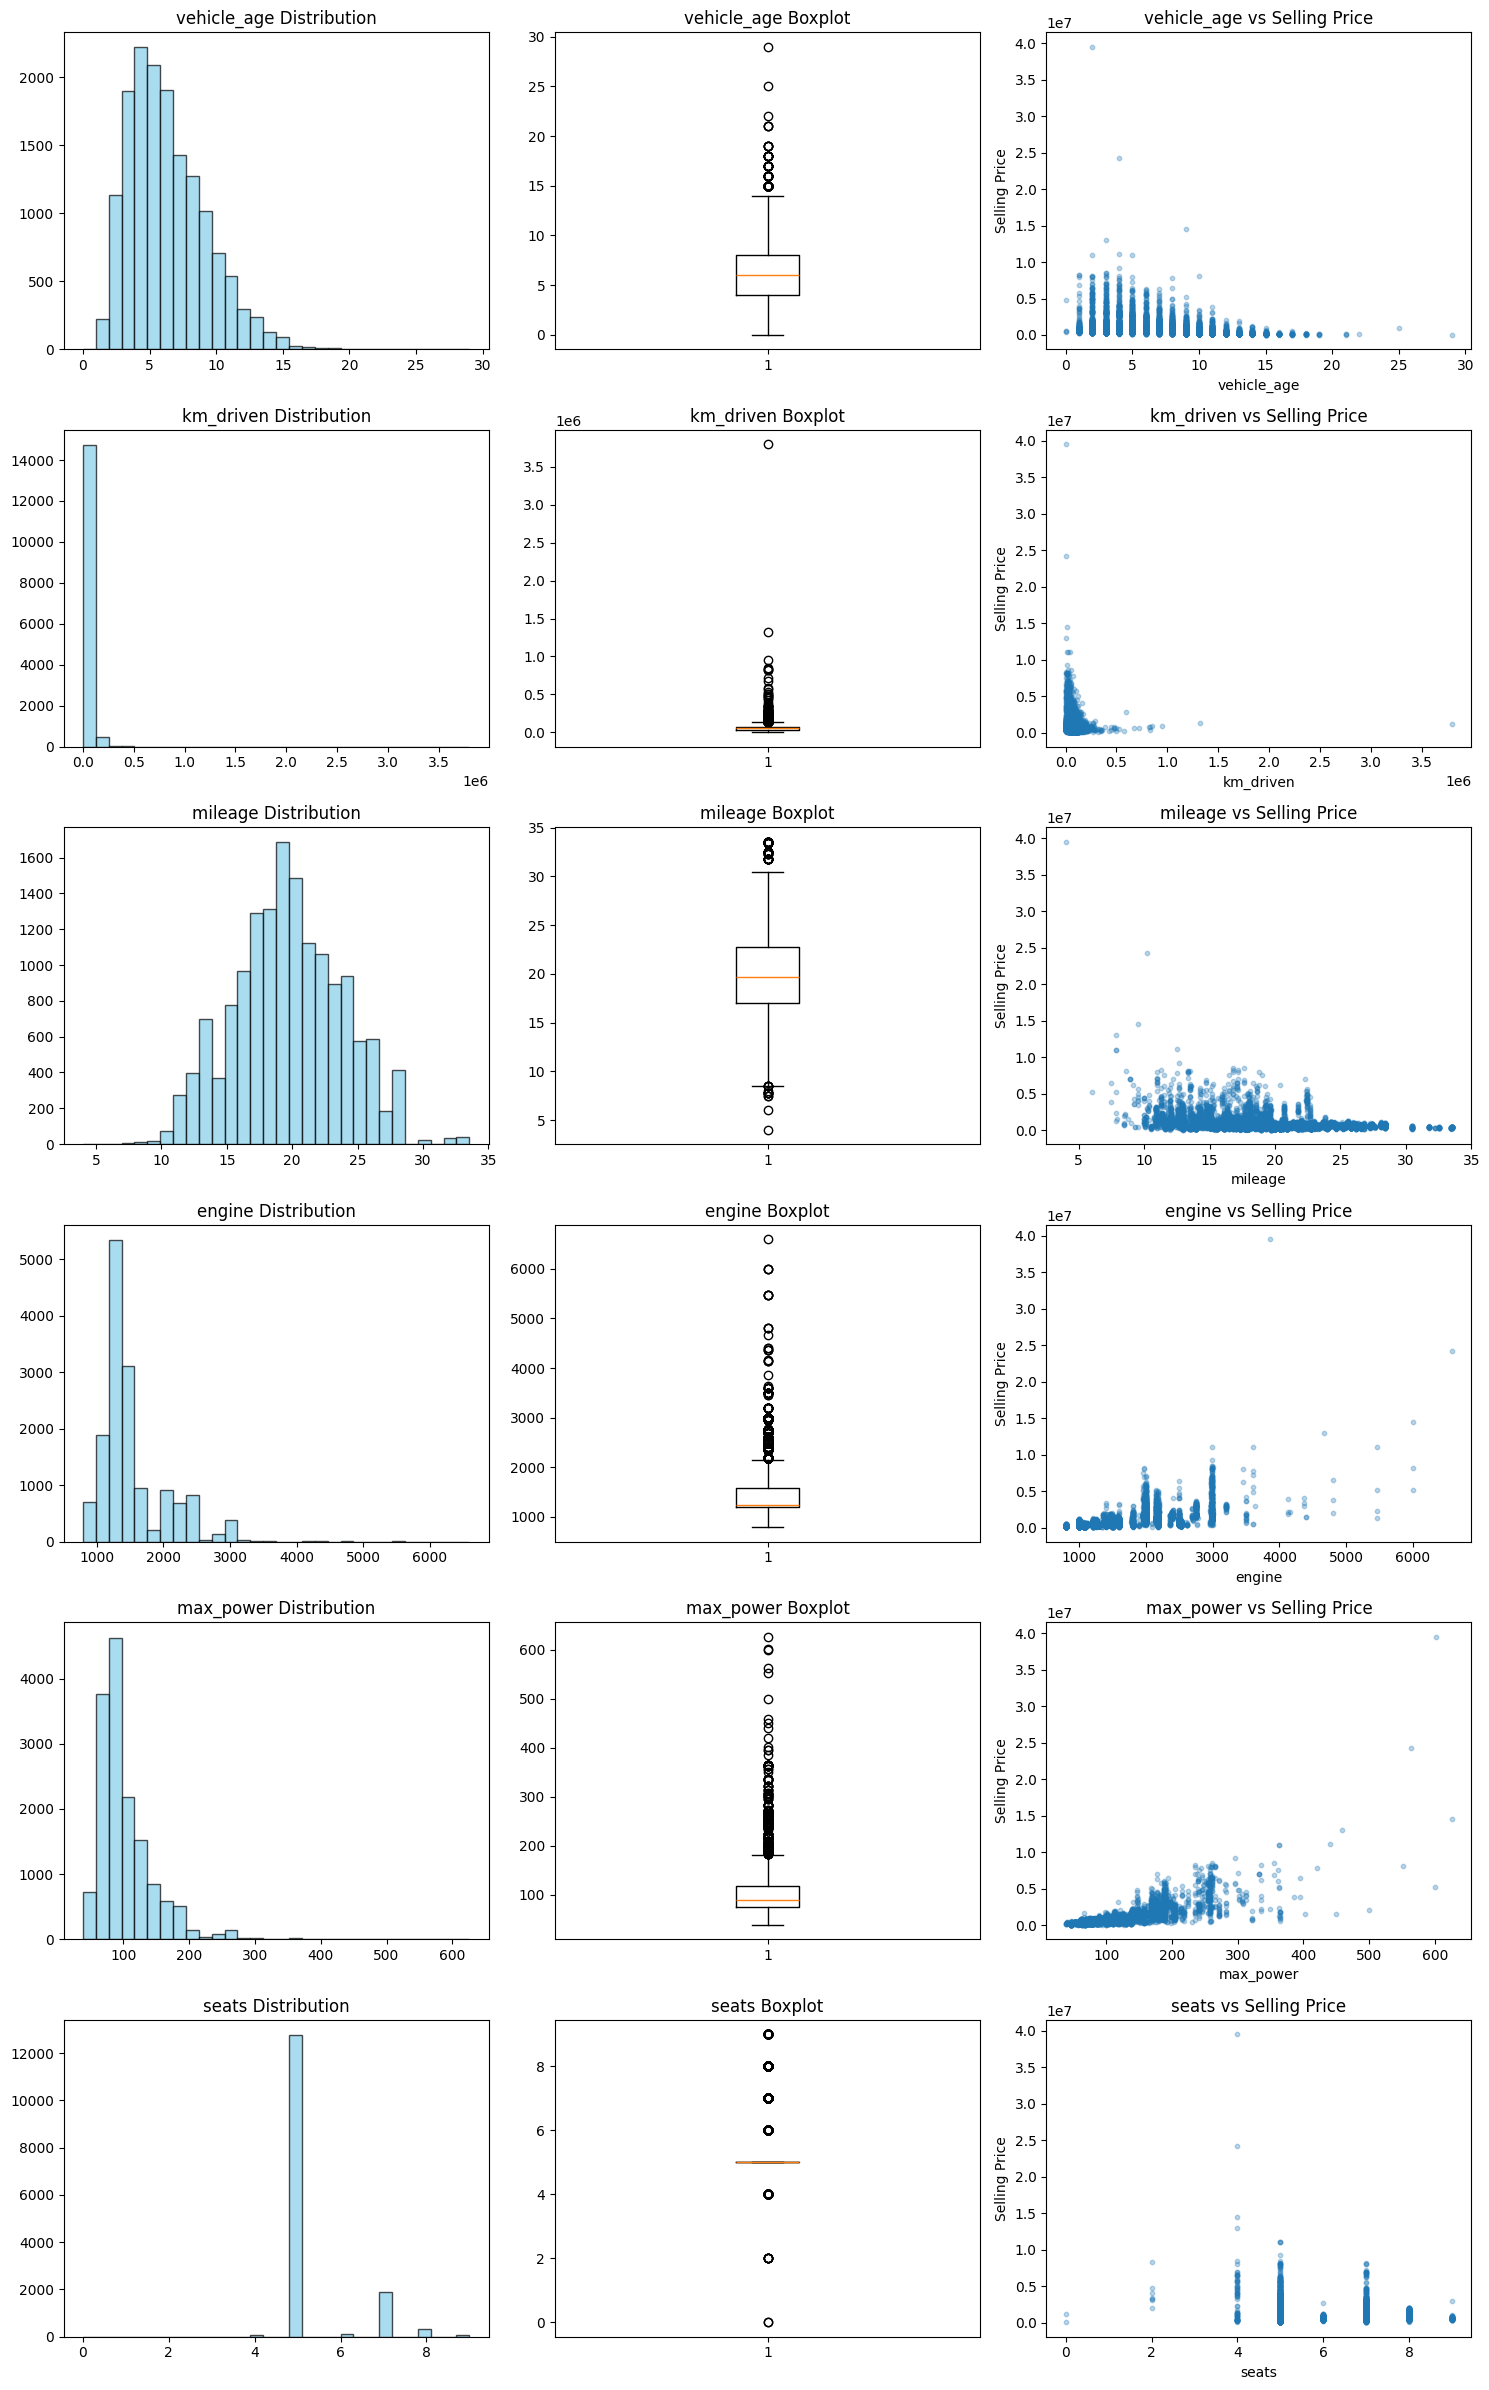

In [51]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f != 'selling_price']

fig, axes = plt.subplots(len(numeric_features), 3, figsize=(15, 4*len(numeric_features)))
if len(numeric_features) == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(numeric_features):
    # Histogram
    axes[i, 0].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'{col} Distribution')

    # Boxplot
    axes[i, 1].boxplot(df[col].dropna())
    axes[i, 1].set_title(f'{col} Boxplot')

    # Scatter vs target
    axes[i, 2].scatter(df[col], df['selling_price'], alpha=0.3, s=10)
    axes[i, 2].set_title(f'{col} vs Selling Price')
    axes[i, 2].set_xlabel(col)
    axes[i, 2].set_ylabel('Selling Price')

plt.tight_layout()
plt.show()


--- Correlation Matrix ---


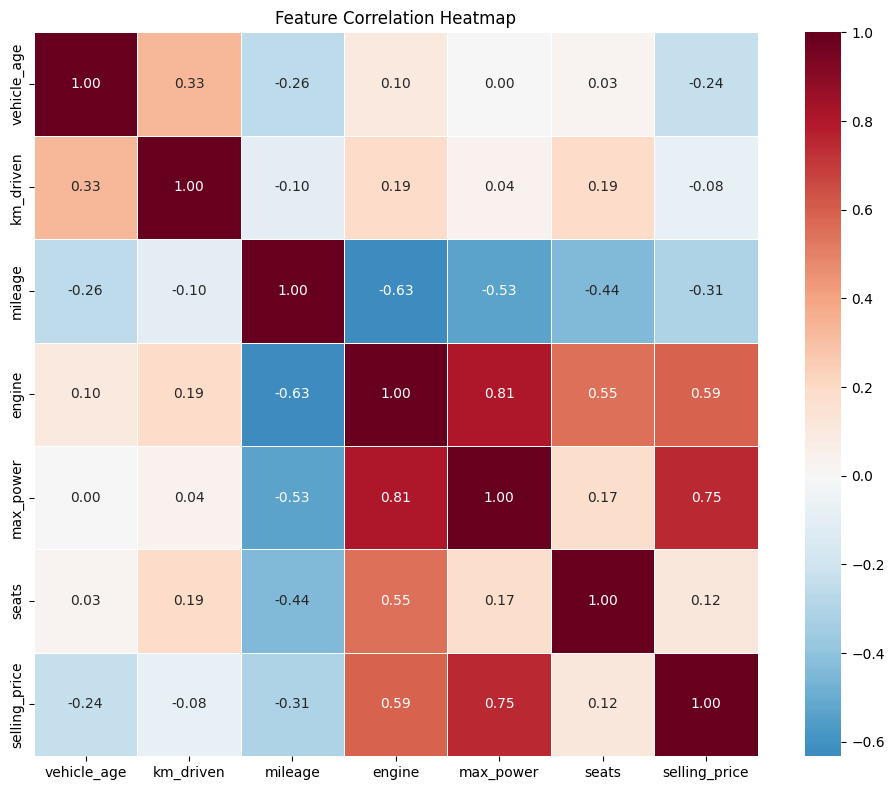


--- High Correlation Pairs (|r| > 0.8) ---
engine <-> max_power: 0.807


In [52]:
#Correlation Analysis
print("\n--- Correlation Matrix ---")
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Check multicollinearity (VIF-like using correlation)
print("\n--- High Correlation Pairs (|r| > 0.8) ---")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
            print(f"{corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

if not high_corr:
    print("No highly correlated pairs found (threshold: 0.8)")


--- Categorical Features: ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type'] ---


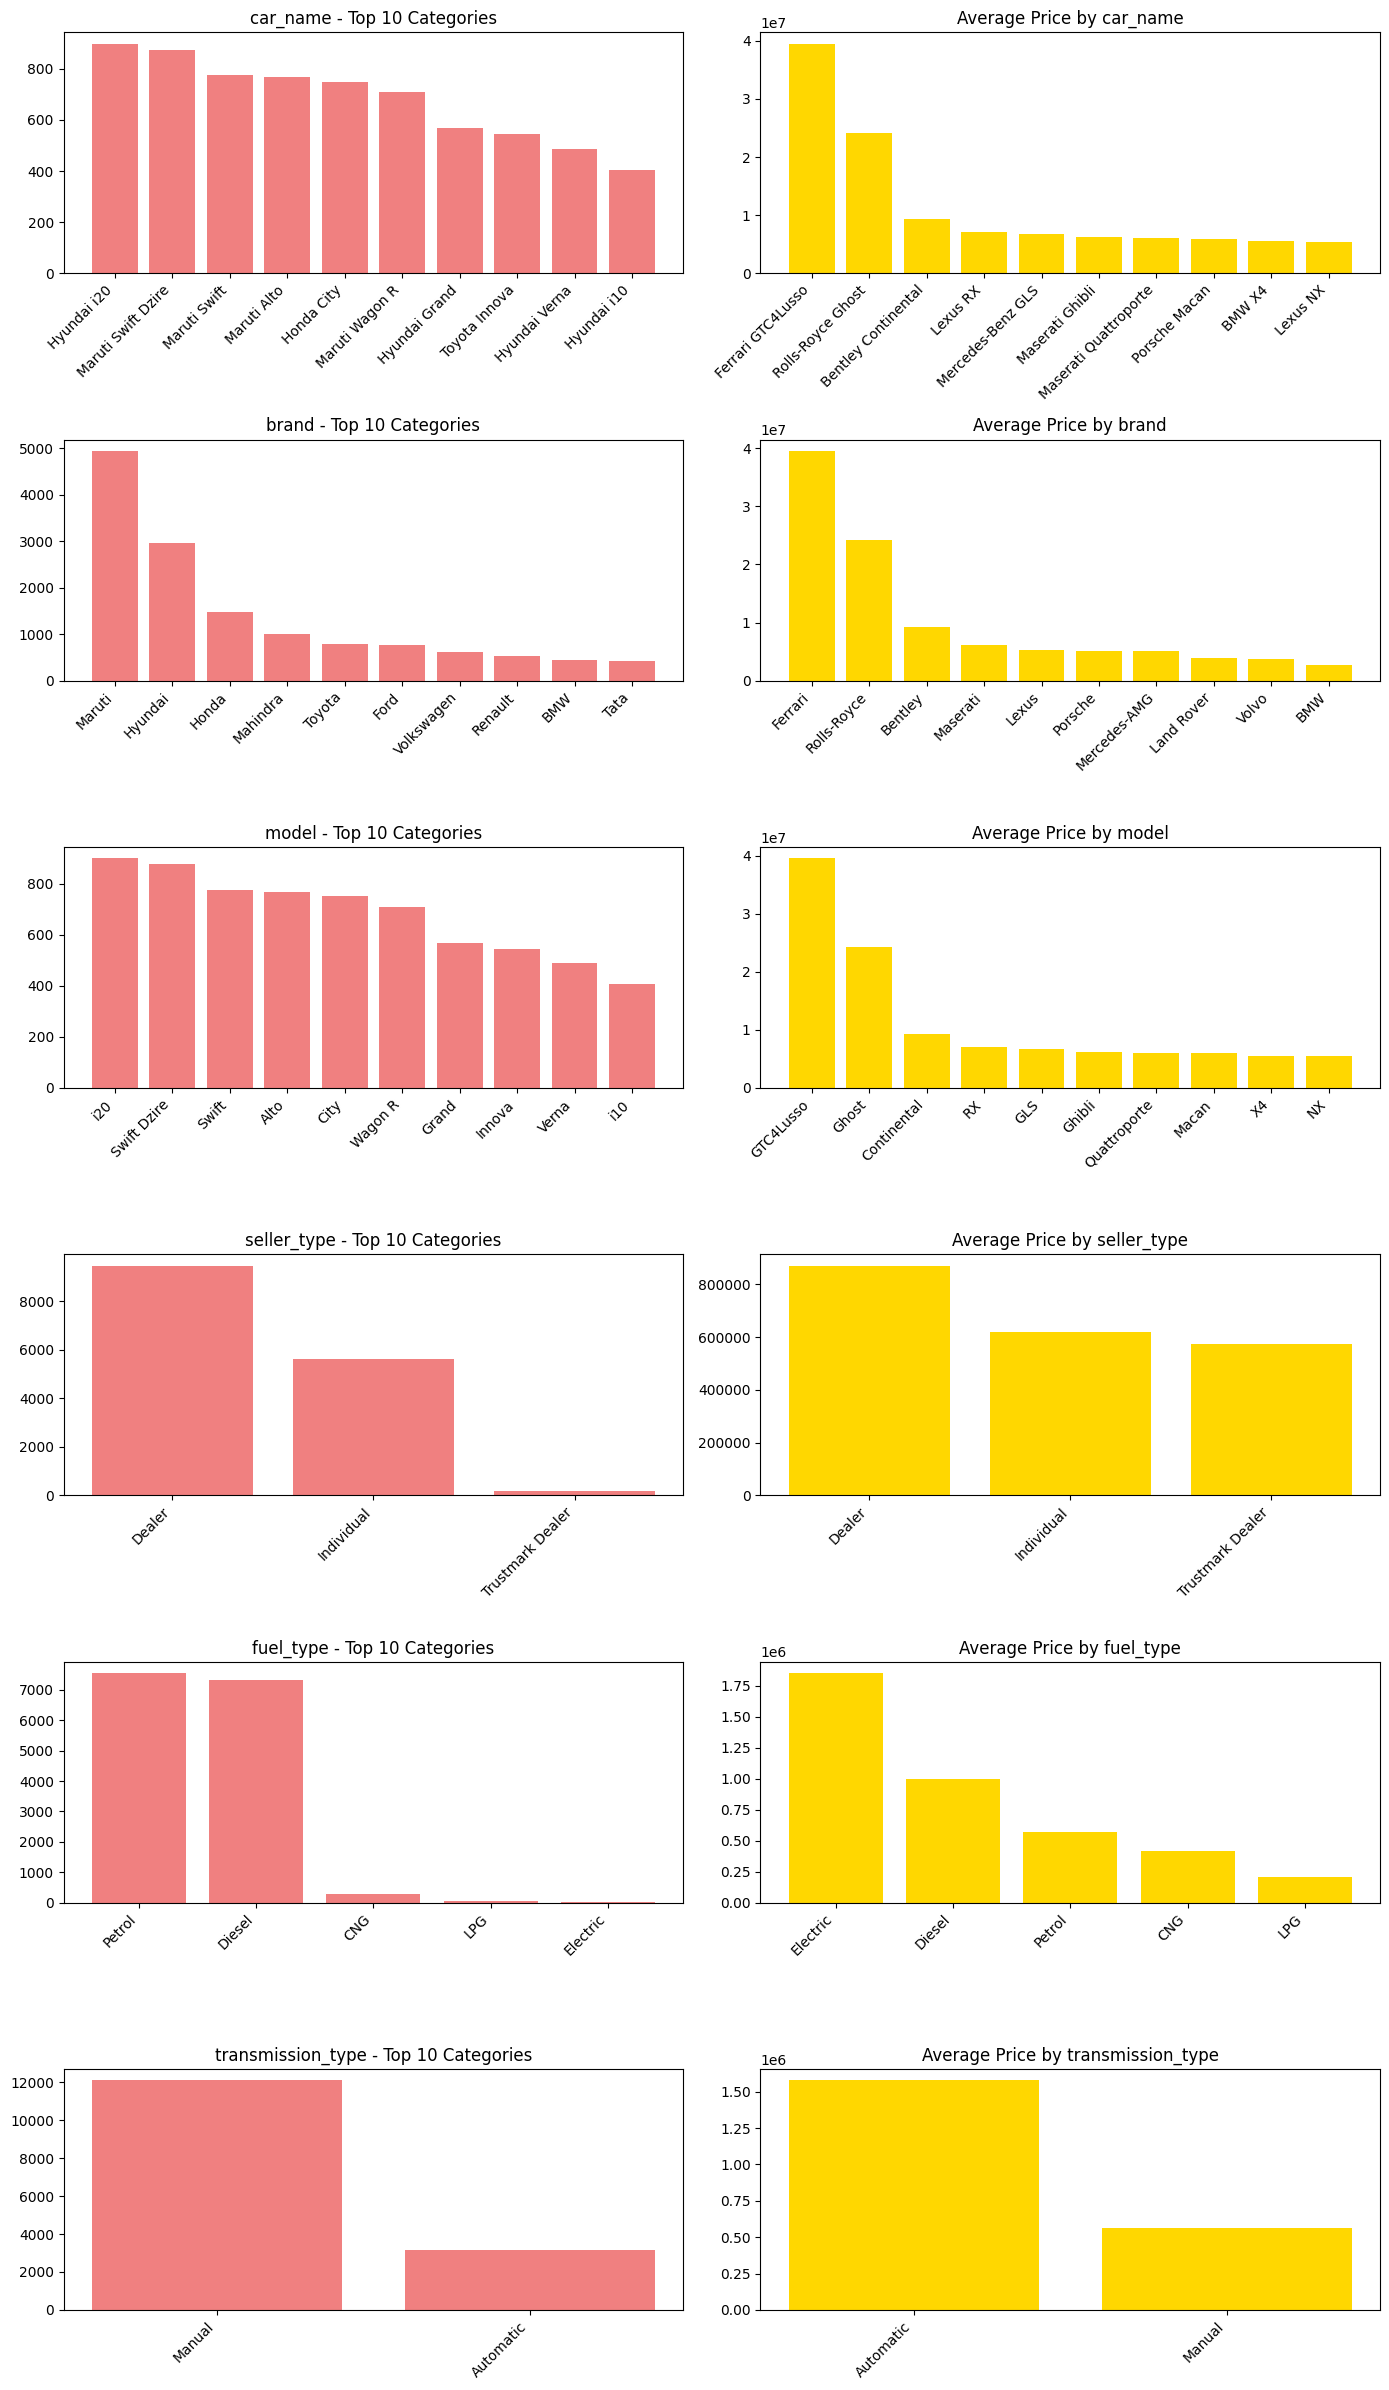

In [53]:
# Categorical Features Analysis
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n--- Categorical Features: {categorical_features} ---")

fig, axes = plt.subplots(len(categorical_features), 2, figsize=(14, 4*len(categorical_features)))
if len(categorical_features) == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(categorical_features):
    # Value counts
    vc = df[col].value_counts().head(10)
    axes[i, 0].bar(range(len(vc)), vc.values, color='lightcoral')
    axes[i, 0].set_title(f'{col} - Top 10 Categories')
    axes[i, 0].set_xticks(range(len(vc)))
    axes[i, 0].set_xticklabels(vc.index, rotation=45, ha='right')

    # Average price by category
    avg_price = df.groupby(col)['selling_price'].mean().sort_values(ascending=False).head(10)
    axes[i, 1].bar(range(len(avg_price)), avg_price.values, color='gold')
    axes[i, 1].set_title(f'Average Price by {col}')
    axes[i, 1].set_xticks(range(len(avg_price)))
    axes[i, 1].set_xticklabels(avg_price.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

#4.Feature Engineering

In [55]:
print("\n" + "=" * 80)
print(" FEATURE ENGINEERING")
print("=" * 80)

df_fe = df.copy()

# Extract brand and model from car_name (if not already separate)
if 'car_name' in df_fe.columns and 'brand' not in df_fe.columns:
    df_fe['brand'] = df_fe['car_name'].apply(lambda x: str(x).split()[0] if pd.notna(x) else 'Unknown')
    df_fe['model'] = df_fe['car_name'].apply(lambda x: ' '.join(str(x).split()[1:]) if pd.notna(x) else 'Unknown')

# Age-based features
if 'vehicle_age' in df_fe.columns:
    df_fe['age_category'] = pd.cut(df_fe['vehicle_age'],
                                   bins=[0, 2, 5, 10, 20, 100],
                                   labels=['New', 'Recent', 'Moderate', 'Old', 'Vintage'])
    df_fe['is_new_car'] = (df_fe['vehicle_age'] <= 2).astype(int)
    df_fe['is_old_car'] = (df_fe['vehicle_age'] > 10).astype(int)

# For older dataset with 'year' instead of 'vehicle_age'
elif 'year' in df_fe.columns:
    current_year = 2024
    df_fe['vehicle_age'] = current_year - df_fe['year']
    df_fe['age_category'] = pd.cut(df_fe['vehicle_age'],
                                   bins=[0, 2, 5, 10, 20, 100],
                                   labels=['New', 'Recent', 'Moderate', 'Old', 'Vintage'])
    df_fe['is_new_car'] = (df_fe['vehicle_age'] <= 2).astype(int)
    df_fe['is_old_car'] = (df_fe['vehicle_age'] > 10).astype(int)

# Power-to-weight ratio proxy (if engine and max_power available)
if 'engine' in df_fe.columns and 'max_power' in df_fe.columns:
    df_fe['power_to_engine'] = df_fe['max_power'] / (df_fe['engine'] + 1)

# Mileage efficiency categories
if 'mileage' in df_fe.columns:
    df_fe['mileage_category'] = pd.qcut(df_fe['mileage'], q=4,
                                         labels=['Low', 'Medium', 'High', 'Very High'],
                                         duplicates='drop')

# Price per year (depreciation indicator)
if 'vehicle_age' in df_fe.columns:
    df_fe['price_per_year'] = df_fe['selling_price'] / (df_fe['vehicle_age'] + 1)

#Engine size categories
if 'engine' in df_fe.columns:
    df_fe['engine_category'] = pd.cut(df_fe['engine'],
                                       bins=[0, 1000, 1500, 2000, 3000, 10000],
                                       labels=['Small', 'Compact', 'Mid', 'Large', 'Luxury'])

# Brand tier (based on average price)
if 'brand' in df_fe.columns:
    brand_avg_price = df_fe.groupby('brand')['selling_price'].mean()
    brand_tiers = pd.qcut(brand_avg_price, q=3, labels=['Budget', 'Mid', 'Premium'])
    df_fe['brand_tier'] = df_fe['brand'].map(brand_tiers.to_dict())

print("\n--- New Features Created ---")
new_features = [c for c in df_fe.columns if c not in df.columns]
print(new_features)

print("\n--- Feature Engineering Complete ---")
print(f"Shape after FE: {df_fe.shape}")


STEP 4: FEATURE ENGINEERING

--- New Features Created ---
['age_category', 'is_new_car', 'is_old_car', 'power_to_engine', 'mileage_category', 'price_per_year', 'engine_category', 'brand_tier']

--- Feature Engineering Complete ---
Shape after FE: (15244, 21)


In [56]:
print("\n" + "=" * 80)
print("PREPROCESSING PIPELINE")
print("=" * 80)

# Define target
target = 'selling_price'
y = df_fe[target].copy()

# Identify feature types
numeric_features_final = df_fe.select_dtypes(include=[np.number]).columns.tolist()
numeric_features_final = [f for f in numeric_features_final if f != target]

categorical_features_final = df_fe.select_dtypes(include=['object', 'category']).columns.tolist()

columns_to_drop = ['car_name']
for col in columns_to_drop:
    if col in numeric_features_final:
        numeric_features_final.remove(col)
    if col in categorical_features_final:
        categorical_features_final.remove(col)

# Prepare X
X = df_fe[numeric_features_final + categorical_features_final].copy()

print(f"\nFinal feature matrix shape: {X.shape}")

# Train-Test Split (BEFORE any preprocessing to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Build Preprocessing Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_final),
        ('cat', categorical_transformer, categorical_features_final)
    ])

# Fit preprocessor on training data ONLY
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = (numeric_features_final +
                 list(preprocessor.named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_features_final)))

print(f"\nProcessed feature count: {len(feature_names)}")


PREPROCESSING PIPELINE

Final feature matrix shape: (15244, 19)

Processed feature count: 179


In [63]:
print("\n" + "=" * 80)
print("MODEL TRAINING & BASELINE COMPARISON")
print("=" * 80)

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    """Train and evaluate a regression model. Returns metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100
    evs = explained_variance_score(y_te, y_pred)

    # Adjusted R²
    n = len(y_te)
    p = X_te.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    metrics = {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Adj_R2': adj_r2,
        'MAPE_%': mape,
        'Exp_Var': evs
    }
    return metrics, y_pred


MODEL TRAINING & BASELINE COMPARISON


In [67]:
results = []

# Linear Regression (Baseline)
print("\nTraining Linear Regression...")
lr = LinearRegression()
lr_metrics, lr_pred = evaluate_model(lr, X_train_processed, X_test_processed, y_train, y_test, 'Linear Regression')
results.append(lr_metrics)

# Ridge Regression
print("Training Ridge Regression...")
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge_metrics, ridge_pred = evaluate_model(ridge, X_train_processed, X_test_processed, y_train, y_test, 'Ridge')
results.append(ridge_metrics)

# Lasso Regression
print("Training Lasso Regression...")
lasso = Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=10000)
lasso_metrics, lasso_pred = evaluate_model(lasso, X_train_processed, X_test_processed, y_train, y_test, 'Lasso')
results.append(lasso_metrics)

# Elastic Net
print("Training Elastic Net...")
en = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000)
en_metrics, en_pred = evaluate_model(en, X_train_processed, X_test_processed, y_train, y_test, 'Elastic Net')
results.append(en_metrics)

# Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeRegressor(max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=RANDOM_STATE)
dt_metrics, dt_pred = evaluate_model(dt, X_train_processed, X_test_processed, y_train, y_test, 'Decision Tree')
results.append(dt_metrics)

# Random Forest
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=10,
                            min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)
rf_metrics, rf_pred = evaluate_model(rf, X_train_processed, X_test_processed, y_train, y_test, 'Random Forest')
results.append(rf_metrics)

# Gradient Boosting
print("Training Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,
                                random_state=RANDOM_STATE)
gb_metrics, gb_pred = evaluate_model(gb, X_train_processed, X_test_processed, y_train, y_test, 'Gradient Boosting')
results.append(gb_metrics)

# AdaBoost
print("Training AdaBoost...")
ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE)
ada_metrics, ada_pred = evaluate_model(ada, X_train_processed, X_test_processed, y_train, y_test, 'AdaBoost')
results.append(ada_metrics)

# Extra Trees
print("Training Extra Trees...")
et = ExtraTreesRegressor(n_estimators=200, max_depth=15, min_samples_split=10,
                           n_jobs=-1, random_state=RANDOM_STATE)
et_metrics, et_pred = evaluate_model(et, X_train_processed, X_test_processed, y_train, y_test, 'Extra Trees')
results.append(et_metrics)

# KNN
print("Training KNN...")
knn = KNeighborsRegressor(n_neighbors=5, weights='distance', n_jobs=-1)
knn_metrics, knn_pred = evaluate_model(knn, X_train_processed, X_test_processed, y_train, y_test, 'KNN')
results.append(knn_metrics)

# SVR (can be slow on large data)
print("Training SVR...")
svr = SVR(kernel='rbf', C=1.0, gamma='scale')
svr_metrics, svr_pred = evaluate_model(svr, X_train_processed, X_test_processed, y_train, y_test, 'SVR')
results.append(svr_metrics)

# XGBoost
if XGBOOST_AVAILABLE:
    print("Training XGBoost...")
    xgb_model = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    xgb_metrics, xgb_pred = evaluate_model(xgb_model, X_train_processed, X_test_processed, y_train, y_test, 'XGBoost')
    results.append(xgb_metrics)

# LightGBM
if LIGHTGBM_AVAILABLE:
    print("Training LightGBM...")
    lgb_model = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
    lgb_metrics, lgb_pred = evaluate_model(lgb_model, X_train_processed, X_test_processed, y_train, y_test, 'LightGBM')
    results.append(lgb_metrics)


Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training Elastic Net...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training AdaBoost...
Training Extra Trees...
Training KNN...
Training SVR...
Training XGBoost...
Training LightGBM...



MODEL COMPARISON RESULTS
            Model           MAE          RMSE        R2    Adj_R2    MAPE_%  Exp_Var
Gradient Boosting  21587.942738  83792.873224  0.988452  0.987732  2.496388 0.988453
          XGBoost  31786.826172 105771.894036  0.981600  0.980452  3.803588 0.981600
         LightGBM  42211.110368 111468.647289  0.979564  0.978289  5.604476 0.979569
    Random Forest  22789.469119 117436.613651  0.977318  0.975902  1.673156 0.977318
      Extra Trees  22991.669058 126672.031008  0.973610  0.971963  2.126528 0.973612
              KNN  80365.235714 153783.830873  0.961104  0.958677 11.856598 0.961220
            Ridge  91170.787468 191202.662422  0.939873  0.936122 13.562218 0.939877
            Lasso  91167.767275 198056.853291  0.935485  0.931460 13.435639 0.935486
Linear Regression  91183.114338 198071.661536  0.935475  0.931449 13.437191 0.935477
    Decision Tree  51773.953679 203903.643718  0.931620  0.927353  5.624460 0.931642
      Elastic Net 110350.877588 209457.

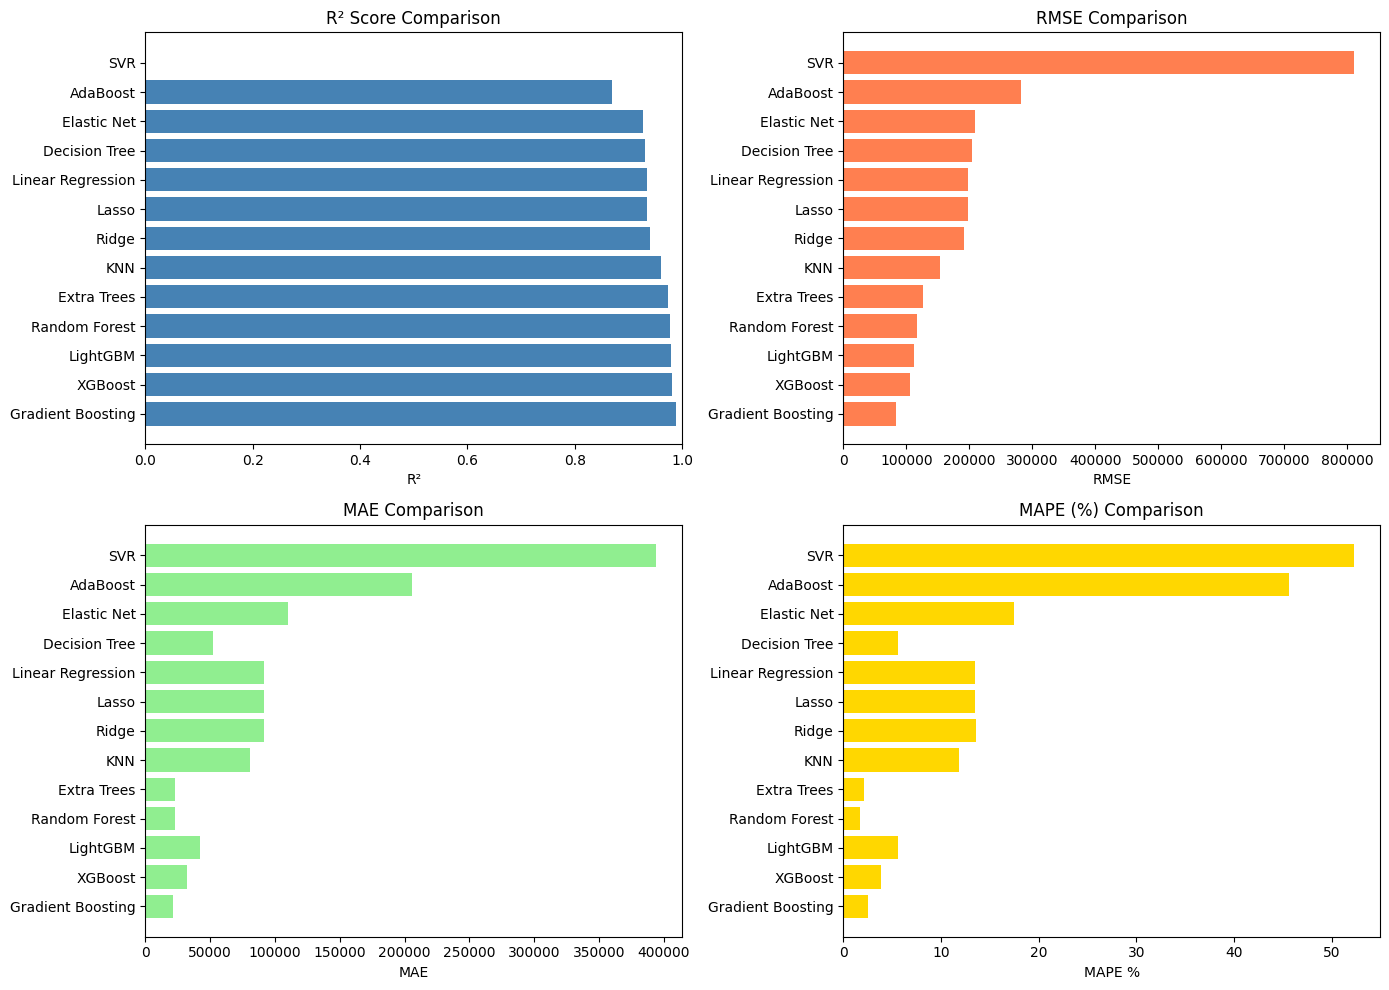

In [68]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)

print("\n" + "=" * 80)
print("MODEL COMPARISON RESULTS")
print("=" * 80)
print(results_df.to_string(index=False))

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# R² comparison
axes[0, 0].barh(results_df['Model'], results_df['R2'], color='steelblue')
axes[0, 0].set_title('R² Score Comparison')
axes[0, 0].set_xlabel('R²')
axes[0, 0].set_xlim(0, 1)

# RMSE comparison
axes[0, 1].barh(results_df['Model'], results_df['RMSE'], color='coral')
axes[0, 1].set_title('RMSE Comparison')
axes[0, 1].set_xlabel('RMSE')

# MAE comparison
axes[1, 0].barh(results_df['Model'], results_df['MAE'], color='lightgreen')
axes[1, 0].set_title('MAE Comparison')
axes[1, 0].set_xlabel('MAE')

# MAPE comparison
axes[1, 1].barh(results_df['Model'], results_df['MAPE_%'], color='gold')
axes[1, 1].set_title('MAPE (%) Comparison')
axes[1, 1].set_xlabel('MAPE %')

plt.tight_layout()
plt.show()

In [69]:
print("\n" + "=" * 80)
print(" CROSS-VALIDATION")
print("=" * 80)

# CV on top 3 models (Standard choices for Tabular data)
top_models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE),
}

if XGBOOST_AVAILABLE:
    top_models['XGBoost'] = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                              random_state=RANDOM_STATE, n_jobs=-1)

cv_results = []
for name, model in top_models.items():
    print(f"\nCross-validating {name}...")
    cv_scores = cross_val_score(model, X_train_processed, y_train,
                                 cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                                 scoring='r2', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV_R2_Mean': cv_scores.mean(),
        'CV_R2_Std': cv_scores.std(),
        'CV_R2_Min': cv_scores.min(),
        'CV_R2_Max': cv_scores.max()
    })
    print(f"  R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)
print("\n--- Cross-Validation Summary ---")
print(cv_df.to_string(index=False))


 CROSS-VALIDATION

Cross-validating Random Forest...
  R²: 0.9312 (+/- 0.1290)

Cross-validating Gradient Boosting...
  R²: 0.9478 (+/- 0.0909)

Cross-validating XGBoost...
  R²: 0.9214 (+/- 0.1576)

--- Cross-Validation Summary ---
            Model  CV_R2_Mean  CV_R2_Std  CV_R2_Min  CV_R2_Max
    Random Forest    0.931240   0.064515   0.810524   0.987882
Gradient Boosting    0.947802   0.045434   0.866137   0.993200
          XGBoost    0.921384   0.078777   0.769974   0.981309


In [71]:
print("\n" + "=" * 80)
print("HYPERPARAMETER TUNING (FAST MODE)")
print("=" * 80)

# Identify best model from CV
best_model_name = cv_df.loc[cv_df['CV_R2_Mean'].idxmax(), 'Model']
print(f"\nBest model from CV: {best_model_name}")

rf_param_grid_fast = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_grid_fast,
    n_iter=10,
    cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

rf_random_search.fit(X_train_processed, y_train)

print(f"\nBest RF Parameters: {rf_random_search.best_params_}")
print(f"Best CV R²: {rf_random_search.best_score_:.4f}")

# Evaluate tuned model
best_rf = rf_random_search.best_estimator_
tuned_rf_metrics, tuned_rf_pred = evaluate_model(
    best_rf, X_train_processed, X_test_processed, y_train, y_test, 'Tuned Random Forest'
)

print("\n--- Tuned Random Forest Performance ---")
for k, v in tuned_rf_metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")


print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS (Headless)")
print("=" * 80)

# Get feature importances from tuned Random Forest
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n--- Top 20 Most Important Features ---")
print(feature_importance_df.head(20).to_string(index=False))


HYPERPARAMETER TUNING (FAST MODE)

Best model from CV: Gradient Boosting
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best RF Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV R²: 0.8710

--- Tuned Random Forest Performance ---
  MAE: 62755.3288
  RMSE: 150593.4749
  R2: 0.9627
  Adj_R2: 0.9604
  MAPE_%: 8.6235
  Exp_Var: 0.9627

FEATURE IMPORTANCE ANALYSIS (Headless)

--- Top 20 Most Important Features ---
                 Feature  Importance
          price_per_year    0.179920
               max_power    0.132439
                  engine    0.074370
         power_to_engine    0.068172
      brand_tier_Premium    0.056358
                 mileage    0.053118
             vehicle_age    0.036779
transmission_type_Manual    0.031014
               km_driven    0.029663
         model_GTC4Lusso    0.028134
           brand_Ferrari    0.023158
          brand_tier_Mid    0.022728
          

In [72]:
# Predictions from best model
y_pred_best = best_rf.predict(X_test_processed)
residuals = y_test.values - y_pred_best

# Residual statistics (Calculated purely mathematically, no plots)
print(f"\nResidual Statistics:")
print(f"  Mean: {np.mean(residuals):.4f} (If this isn't close to 0, the model is biased)")
print(f"  Std: {np.std(residuals):.4f}")
print(f"  Skewness: {skew(residuals):.4f}")
print(f"  Normality (Shapiro p-value): {stats.shapiro(residuals[:5000])[1]:.4f} (>0.05 means perfectly normal)")


Residual Statistics:
  Mean: 1942.8640 (If this isn't close to 0, the model is biased)
  Std: 150580.9416
  Skewness: 1.6021
  Normality (Shapiro p-value): 0.0000 (>0.05 means perfectly normal)


In [73]:
# Build complete pipeline: Preprocessor + Tuned Model
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', best_rf)
])

# Fit on the full training data
final_pipeline.fit(X_train, y_train)

# Final evaluation
y_pred_final = final_pipeline.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)
final_mape = mean_absolute_percentage_error(y_test, y_pred_final) * 100

print(f"\n--- FINAL MODEL PERFORMANCE ---")
print(f"  MAE:  {final_mae:.4f} Lakhs")
print(f"  RMSE: {final_rmse:.4f} Lakhs")
print(f"  R²:   {final_r2:.4f}")
print(f"  MAPE: {final_mape:.2f}%")

# Prediction interval estimate
print("\n--- Prediction Interval Estimate ---")
print(f"  95% of predictions fall within +/- {1.96 * final_rmse:.2f} Lakhs of the actual market price.")


--- FINAL MODEL PERFORMANCE ---
  MAE:  62755.3288 Lakhs
  RMSE: 150593.4749 Lakhs
  R²:   0.9627
  MAPE: 8.62%

--- Prediction Interval Estimate ---
  95% of predictions fall within +/- 295163.21 Lakhs of the actual market price.
